# Labwork on “Ensemble learning”

## Exercise 1

### A

In [5]:
# (a)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, RepeatedKFold
from sklearn.metrics import r2_score
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import shap

# (a) Load the 'diabetes' dataset
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

print(f"Dataset loaded successfully. Features count: {X.shape[1]}, Samples: {X.shape[0]}")

Dataset loaded successfully. Features count: 10, Samples: 442


--- 1. Dataset Shape and Data Types ---
Dataset shape (rows, columns): (442, 10)

Data types of features:
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object

Missing values count: 0

--- 2. Unique Values Count per Feature ---
age     58
sex      2
bmi    163
bp     100
s1     141
s2     302
s3      63
s4      66
s5     184
s6      56
dtype: int64

Unique encoded values for 'sex' feature:
[ 0.05068012 -0.04464164]

--- 3. Target Variable (y) Summary Statistics ---
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


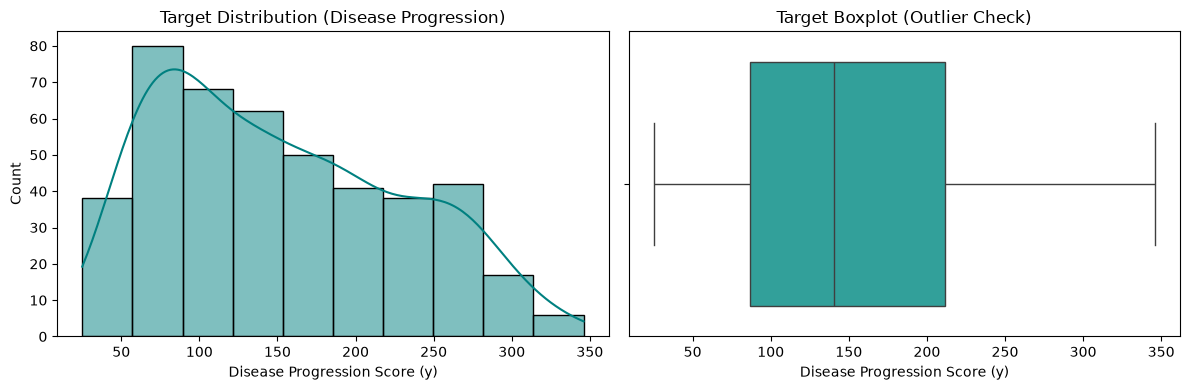


--- 4. Feature Summary Statistics ---
             mean       std       min       50%       max
age -2.511817e-19  0.047619 -0.107226  0.005383  0.110727
sex  1.230790e-17  0.047619 -0.044642 -0.044642  0.050680
bmi -2.245564e-16  0.047619 -0.090275 -0.007284  0.170555
bp  -4.797570e-17  0.047619 -0.112399 -0.005670  0.132044
s1  -1.381499e-17  0.047619 -0.126781 -0.004321  0.153914
s2   3.918434e-17  0.047619 -0.115613 -0.003819  0.198788
s3  -5.777179e-18  0.047619 -0.102307 -0.006584  0.181179
s4  -9.042540e-18  0.047619 -0.076395 -0.002592  0.185234
s5   9.268604e-17  0.047619 -0.126097 -0.001947  0.133597
s6   1.130318e-17  0.047619 -0.137767 -0.001078  0.135612


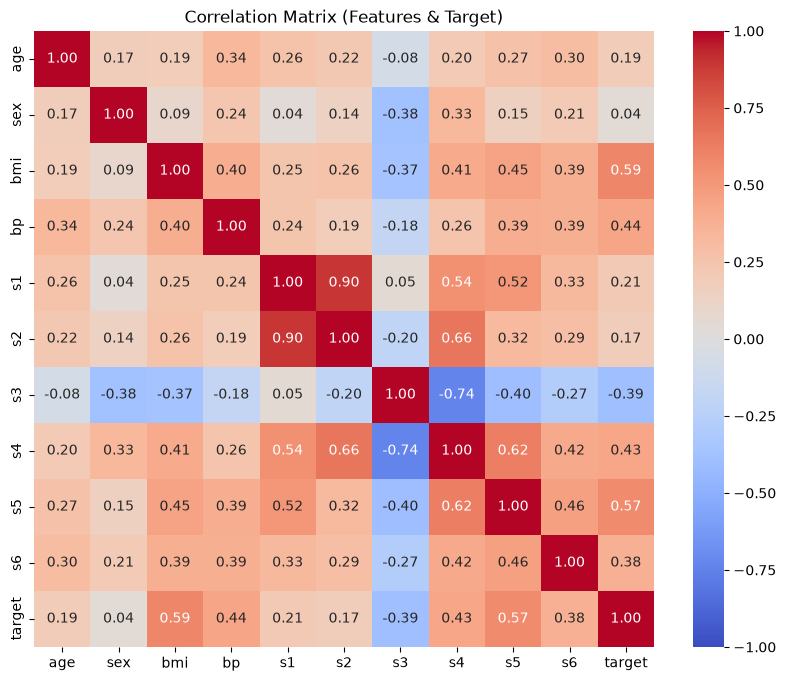

In [3]:
# 1. Inspect features and data types
print("--- 1. Dataset Shape and Data Types ---")
print(f"Dataset shape (rows, columns): {X.shape}")
print("\nData types of features:")
print(X.dtypes)

print("\nMissing values count:", X.isnull().sum().sum())

# 2. Inspect unique values for features (checking discrete/categorical-like columns)
print("\n--- 2. Unique Values Count per Feature ---")
print(X.nunique())

print("\nUnique encoded values for 'sex' feature:")
print(X['sex'].unique())

# 3. Target variable (y) summary and distribution analysis
print("\n--- 3. Target Variable (y) Summary Statistics ---")
print(y.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution histogram & KDE
sns.histplot(y, kde=True, ax=axes[0], color='teal')
axes[0].set_title("Target Distribution (Disease Progression)")
axes[0].set_xlabel("Disease Progression Score (y)")

# Boxplot to inspect potential target outliers
sns.boxplot(x=y, ax=axes[1], color='lightseagreen')
axes[1].set_title("Target Boxplot (Outlier Check)")
axes[1].set_xlabel("Disease Progression Score (y)")

plt.tight_layout()
plt.show()

# 4. Additional Insights: Feature Summary Statistics & Correlation Heatmap
print("\n--- 4. Feature Summary Statistics ---")
print(X.describe().T[['mean', 'std', 'min', '50%', 'max']])

# Correlation matrix including the target variable
df_full = X.copy()
df_full['target'] = y

plt.figure(figsize=(10, 8))
sns.heatmap(df_full.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Features & Target)")
plt.show()

### B

In [7]:
# (b) Validate the predictive power using 5-fold cross-validation (500 trees each)
models = ['dummy', 'forest', 'xgb']

dummy = DummyRegressor()
forest = RandomForestRegressor(n_estimators=500, n_jobs=-1)
xgb_regressor = XGBRegressor(n_estimators=500, n_jobs=-1)
n_fold = 4
n_repeats = 5
cv = RepeatedKFold(n_splits=n_fold, n_repeats=n_repeats, random_state=1)

dummy_scores = pd.Series(- cross_val_score(dummy, X, y, cv=cv, scoring='neg_root_mean_squared_error'))
forest_scores = pd.Series(- cross_val_score(forest, X, y, cv=cv, scoring='neg_root_mean_squared_error'))
xgb_scores = pd.Series(- cross_val_score(xgb_regressor, X, y, cv=cv, scoring='neg_root_mean_squared_error'))

scores = pd.concat([dummy_scores, forest_scores, xgb_scores], axis=1)
scores.columns = models
melted_scores = pd.melt(scores)
melted_scores.columns = ["model", "RMSE"]
print(scores.mean())

dummy     77.096785
forest    57.748031
xgb       63.725806
dtype: float64


/var/folders/bm/6508_k4d0nl3sbkvytgtw2vr0000gn/T/ipykernel_10188/2429167454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="model", y="RMSE", data=melted_scores, palette="pastel")


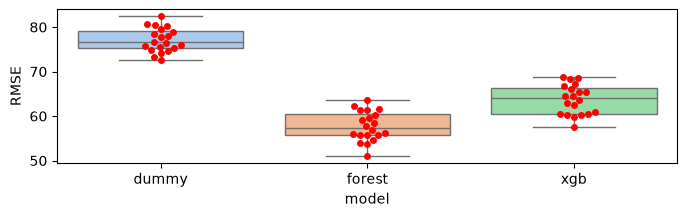

In [8]:
fig, axs = plt.subplots(figsize=(8, 2))

ax = sns.boxplot(x="model", y="RMSE", data=melted_scores, palette="pastel")
ax = sns.swarmplot(x="model", y="RMSE", data=melted_scores, color="red", size=5)

plt.show()

### C

In [14]:
# (c) Train the models on the whole dataset and evaluate on the same data
forest.fit(X, y)
xgb_regressor.fit(X, y)

# Note: model.score(X, y) computes the R-squared (R^2) coefficient of determination
rf_r2 = forest.score(X, y)
xgb_r2 = xgb_regressor.score(X, y)

print("--- Training Set Evaluation (R^2 Score) ---")
print(f"Random Forest Training R^2 score:    {rf_r2}")
print(f"XGBoost Regressor Training R^2 score: {xgb_r2}")

--- Training Set Evaluation (R^2 Score) ---
Random Forest Training R^2 score:    0.9219305983544956
XGBoost Regressor Training R^2 score: 0.9999999997258104


### D

In [19]:
# (d) Compute 3 types of feature importance: Gini (MDI/Gain), Permutation, and SHAP
# 1. Gini / MDI (Built-in Feature Importances)
forest_gini = forest.feature_importances_
xgb_gini = xgb_regressor.feature_importances_

In [16]:
# 2. Permutation Importance
forest_perm = permutation_importance(forest, X, y, n_repeats=10, random_state=42, scoring='r2').importances_mean
xgb_perm = permutation_importance(xgb_regressor, X, y, n_repeats=10, random_state=42, scoring='r2').importances_mean

In [17]:
# 3. Shapley-based Importance (TreeSHAP)
forest_explainer = shap.TreeExplainer(forest)
forest_shap_values = forest_explainer.shap_values(X)
forest_shap_imp = np.abs(forest_shap_values).mean(axis=0)

xgb_explainer = shap.TreeExplainer(xgb_regressor)
xgb_shap_values = xgb_explainer.shap_values(X)
xgb_shap_imp = np.abs(xgb_shap_values).mean(axis=0)

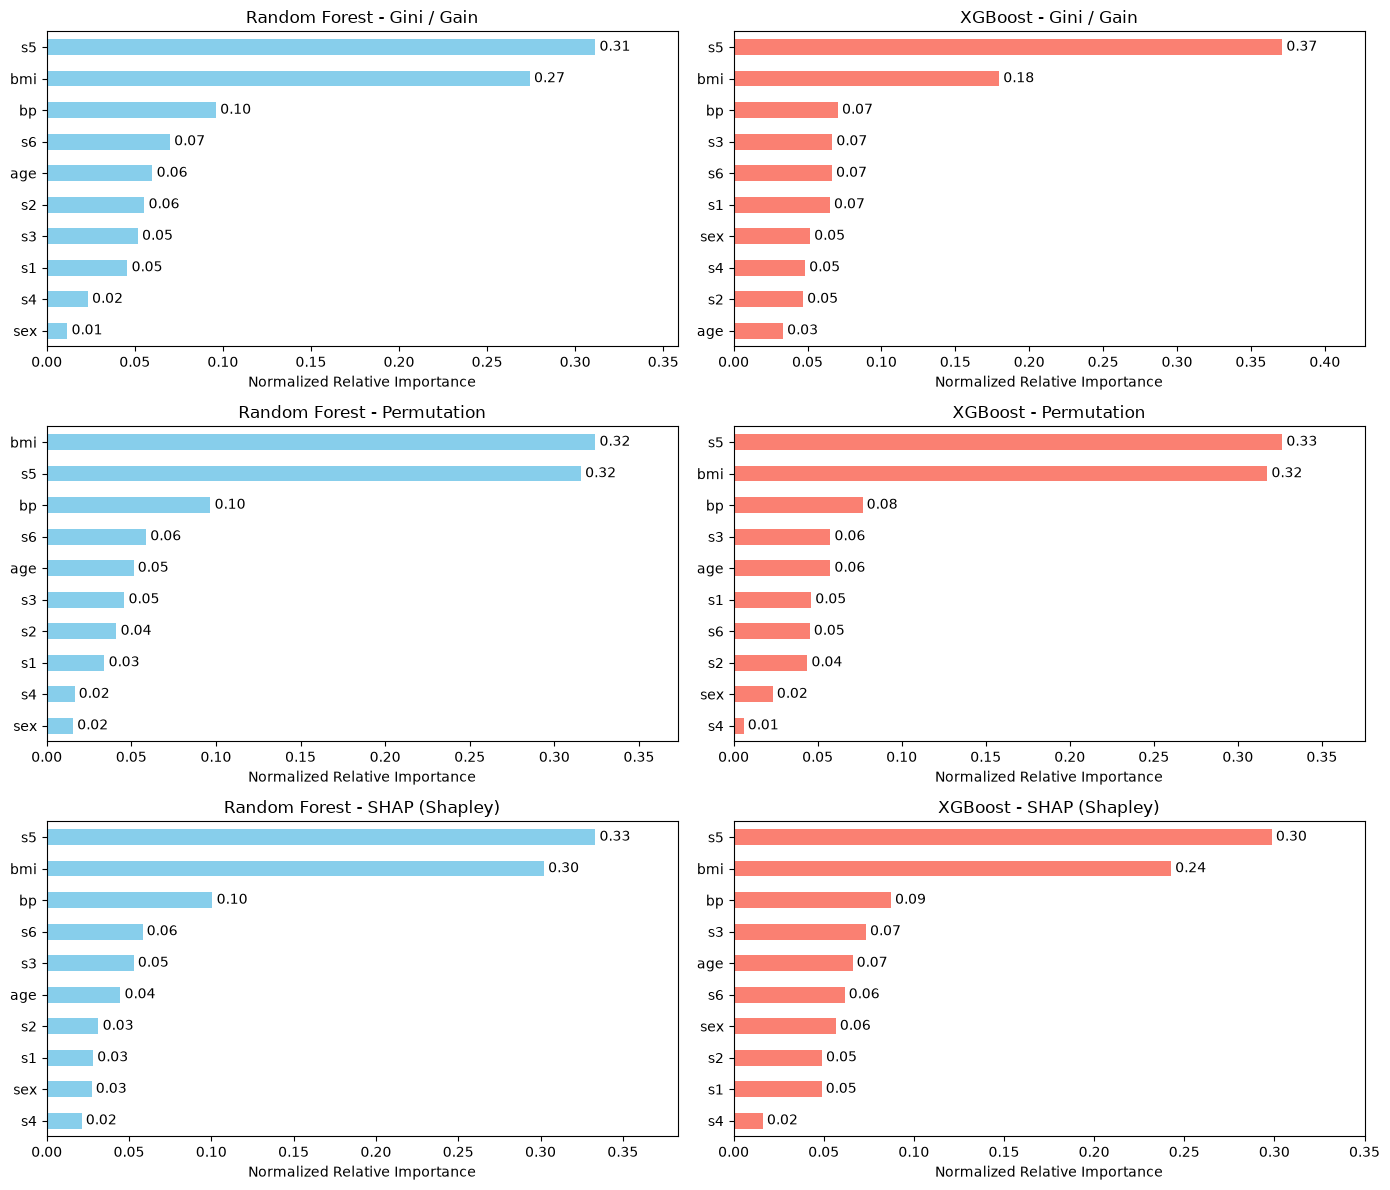

In [22]:
# Create DataFrame for plotting comparisons
feature_names = X.columns

importance_df = pd.DataFrame({
    'Forest_Gini': forest_gini,
    'Forest_Permutation': forest_perm,
    'Forest_SHAP': forest_shap_imp,
    'XGB_Gini': xgb_gini,
    'XGB_Permutation': xgb_perm,
    'XGB_SHAP': xgb_shap_imp
}, index=feature_names)

# Normalize importances for a clear visual comparison (sum to 1)
importance_df_norm = importance_df.div(importance_df.sum(axis=0), axis=1)

# Plotting Feature Importances (sharex=False to allow independent tick labels if needed)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

metrics = [('Gini / Gain', 'Forest_Gini', 'XGB_Gini'),
           ('Permutation', 'Forest_Permutation', 'XGB_Permutation'),
           ('SHAP (Shapley)', 'Forest_SHAP', 'XGB_SHAP')]

for row_idx, (metric_label, rf_col, xgb_col) in enumerate(metrics):
    # --- Random Forest Plot ---
    ax_rf = axes[row_idx, 0]
    data_rf = importance_df_norm[rf_col].sort_values()
    bars_rf = data_rf.plot(kind='barh', ax=ax_rf, color='skyblue')
    ax_rf.set_title(f"Random Forest - {metric_label}")
    ax_rf.set_xlabel("Normalized Relative Importance")
    ax_rf.set_xlim(0, max(data_rf.max() * 1.15, 0.35)) # Extra space for data labels

    # Add exact numerical values on top of bars
    ax_rf.bar_label(ax_rf.containers[0], fmt='%.2f', padding=3)

    # --- XGBoost Plot ---
    ax_xgb = axes[row_idx, 1]
    data_xgb = importance_df_norm[xgb_col].sort_values()
    bars_xgb = data_xgb.plot(kind='barh', ax=ax_xgb, color='salmon')
    ax_xgb.set_title(f"XGBoost - {metric_label}")
    ax_xgb.set_xlabel("Normalized Relative Importance")
    ax_xgb.set_xlim(0, max(data_xgb.max() * 1.15, 0.35)) # Extra space for data labels

    # Add exact numerical values on top of bars
    ax_xgb.bar_label(ax_xgb.containers[0], fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Conclusion & Comparison of Feature Importances (Exercise 1)

#### 1. Primary Feature Importance Drivers
Across both models (**Random Forest** and **XGBoost**) and all three evaluation metrics (**Gini/Gain**, **Permutation**, and **SHAP**), two features consistently dominate the predictive power for diabetes progression:
* **`s5` (Serum Triglycerides level):** Accounts for approximately **30% to 37%** of the total relative importance across all metrics.
* **`bmi` (Body Mass Index):** Accounts for approximately **18% to 32%** of the total relative importance.
* **`bp` (Blood Pressure):** Consistently ranks as the **3rd most important feature**, holding a stable relative importance of **7% to 10%**.

Together, `s5`, `bmi`, and `bp` account for over **65–70%** of the predictive decision-making power in both regressors. Secondary features like `s6` (blood sugar) and `s3` (high-density lipoproteins) contribute modestly, while features like `sex` and `s4` consistently show minimal predictive contribution.

---

#### 2. Comparison Between Feature Importance Metrics

* **Gini / Gain (Built-in Tree Metrics):**
  * **Behavior:** Measures the total reduction in variance/impurity provided by splits on a given feature across all trees.
  * **Observation:** In XGBoost, native `Gain` heavily concentrates importance on `s5` (**0.37**) while underestimating `bmi` (**0.18**). In Random Forest, Gini distributes weight slightly more smoothly (`s5`: **0.31**, `bmi`: **0.27**).
  * **Limitation:** Built-in tree importances can be biased toward continuous features with high variance or features picked early in sequential splitting, making them prone to distortions if trees overfit.

* **Permutation Importance:**
  * **Behavior:** Evaluates the actual drop in model performance ($R^2$) when feature values are randomly shuffled.
  * **Observation:** Permutation importance balances the contributions of `bmi` and `s5` almost equally (**0.32 vs 0.32** in Random Forest; **0.32 vs 0.33** in XGBoost).
  * **Advantage:** Because it measures the impact on prediction error directly, it provides a much more realistic view of how much performance is lost without each feature.

* **SHAP (Shapley Additive exPlanations):**
  * **Behavior:** Grounded in cooperative game theory, TreeSHAP calculates the exact marginal contribution of each feature across all possible feature combinations (coalitions).
  * **Observation:** SHAP values closely align with Permutation importance (`s5`: **0.33/0.30**, `bmi`: **0.30/0.24**, `bp`: **0.10/0.09**), offering a smooth and theoretically sound importance distribution.
  * **Advantage:** SHAP is consistent, model-agnostic, and accounts for feature interactions better than simple single-column permutations or impurity counts.

---

#### 3. Model Comparison: Random Forest vs. XGBoost

* **Random Forest (Bagging):**
  * Builds independent trees in parallel using bootstrapped samples and random feature subsets.
  * This random subsampling encourages feature diversity across trees, leading to very similar and highly consistent feature rankings across Gini, Permutation, and SHAP.

* **XGBoost (Boosting):**
  * Builds trees sequentially, where each new tree fits the residual errors of the previous ones.
  * The native `Gain` metric tends to heavily reward the primary split feature (`s5`). However, when evaluated with **Permutation** or **SHAP**, XGBoost's feature ranking converges to almost the exact same profile as Random Forest, confirming that both models rely on the same underlying physical relationships in the data.

---

#### Summary
While built-in **Gini/Gain** metrics offer a quick baseline, they can skew importance towards early-split variables (especially in boosting algorithms). **Permutation** and **SHAP** importance provide a far more robust, realistic, and interpretable assessment of feature significance for Explainable AI (XAI).

## Exercise 2

## Exercise 3

In [ ]:
# (a)


In [ ]:
# (b)


The most accurate model are the knn and the tree, no real predictive power for the neural network.

In [ ]:
# (c)

In [ ]:
# (d)


In [ ]:
# (e)


In [ ]:
# (f)


In [ ]:
# pip install scikit-optimize

In [ ]:
# (g)


In [ ]:
# (h)
